# We Rate Dogs Project
## Table of contents:
- [Introduction](#Introduction)
- [Data-Gathering](#Data-gathering)
- [Data Assesment](#Data-Assesment)
- [Data Cleaning](#Data-Cleaning)
- [Storing Data](#Storing-Data)
- [Analyzing and Visualizing Data](#Analyzing-and-Visualizing-Data)


In [411]:
import pandas as pd
import requests
import json
import numpy as np

In [412]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)

# Introduction:

> Welcome to the analysis of the WeRateDogs Twitter page data. This is the final project for the Udacity Level 3 course, where we will apply the knowledge we have gained throughout the program. <br>
> We will start by gathering our databases, which consist of three main files: <br>
> 1. **Twitter Archive Enhanced** (`twitter-archive-enhanced.csv`):<br>
 This database contains information about the tweets, including the tweet text, source, tweet ID, retweet ID, and details about the dogs featured in the tweets, such as their names and ages.<br>
> 2. **Image Prediction** (`image-predictions.tsv`): 
<br> This file provides information about the AI predictions made for the dog images included in each tweet.<br>
> 3. **Tweet JSON** (`tweet-json.txt`): <br> This file includes additional data about each tweet, such as the number of likes and retweets.<br>
> Now, let's embark on our journey to wrangle this data!

# Data Gathering:

importing first dataset to our project (twitter_archive_enhanced.csv)

In [413]:
df_archive = pd.read_csv("twitter-archive-enhanced.csv")

Importing our second dataset to our project (image_predictions.tsv) by requesting it

In [414]:
url = "https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv"
response = requests.get(url)
# Check if the request was successful
if response.status_code == 200:
    # Save the content to a file
    with open('image_predictions.tsv', 'wb') as file:
        file.write(response.content)
    print('Dataset downloaded successfully.')
else:
    print(f'Failed to download dataset. Status code: {response.status_code}')

Dataset downloaded successfully.


In [415]:
df_predictions = pd.read_csv("image_predictions.tsv", sep="\t")

Importing our third dataset to our project (tweet-json.txt)

In [416]:
tweet_list = []
with open("tweet-json.txt", encoding='utf-8') as file:
    line = file.readline()
    while line:
        json_obj = json.loads(line)
        tweet_list.append(json_obj)
        line = file.readline()
df_tweet = pd.DataFrame(tweet_list)

# Data Assesment:

### Quality issues:
* in twitter archive database:
    1. Removing retweets rows.
    2. Removing columns related to retweets after removing the to handle NAN values.
    3. Remove the unnessary columns for our analyzation.
    4. Handle duplicates.
    5. Handling rows that doesn't have values for age.
* in image predictions database:<br>
    6. create breed column and gather its data from the other columns.<br>
    7. I need only ['tweet_id', 'breed'] columns only from this database.<br>
    8. wrong data types for tweet id <br>

* in tweet-json database:<br>
    9. Removing retweets rows.<br>
    10. I need only ['id', 'retweet_count', 'favorite_count'] columns. <br>


### Tidiness issues:
* in twitter archive database:
    1. compine the columns['doggo', 'floofer', 'pupper', 'puppo'] to one column called age.
    2. wrong data types for ['tweet_id', 'timestamp'] 


#### Assesment for twitter archive enhanced database <br>
* starting with visual assesment:

In [417]:
df_archive.head(10)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643555336193/photo/1,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421306343426/photo/1,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181378084864/photo/1,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557279858688/photo/1,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",NaN,NaN,NaN,"https://twitter.com/dog_rates/status/891327558926688256/photo/1,https://twitter.com/dog_rates/status/891327558926688256/photo/1",12,10,Franklin,NaN,NaN,NaN,NaN
5,891087950875897856,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",Here we have a majestic great white breaching off South Africa's coast. Absolutely h*ckin breathtaking. 13/10 (IG: tucker_marlo) #BarkWeek https://t.co/kQ04fDDRmh,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950875897856/photo/1,13,10,NaN,NaN,NaN,NaN,NaN
6,890971913173991426,NaN,NaN,2017-07-28 16:27:12 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",Meet Jax. He enjoys ice cream so much he gets nervous around it. 13/10 help Jax enjoy more things by clicking below\n\nhttps://t.co/Zr4hWfAs1H https://t.co/tVJBRMnhxl,NaN,NaN,NaN,"https://gofundme.com/ydvmve-surgery-for-jax,https://twitter.com/dog_rates/status/890971913173991426/photo/1",13,10,Jax,NaN,NaN,NaN,NaN
7,890729181411237888,NaN,NaN,2017-07-28 00:22:40 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",When you watch your owner call another dog a good boy but then they turn back to you and say you're a great boy. 13/10 https://t.co/v0nONBcwxq,NaN,NaN,NaN,"https://twitter.com/dog_rates/status/890729181411237888/photo/1,https://twitter.com/dog_rates/status/890729181411237888/photo/1",13,10,NaN,NaN,NaN,NaN,NaN
8,890609185150312448,NaN,NaN,2017-07-27 16:25:51 +0000,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",This is Zoey. She doesn't want to be one of the scary sharks. Just wants to be a snuggly pettable boatpet. 13/10 #BarkWeek https://t.co/9TwLuAGH0b,NaN,NaN,NaN,https://twitter.com/dog_rates/status/890609185150312448/photo/1,13,10,Zoey,NaN,NaN,NaN,NaN
9,890240255349198849,NaN,NaN,2017-07-26 15:59:51 +0

**Conclusion**
> * to remove retweets there are many signs refer to that they are retweets. First: columns like (in_reply_to_status_id,retweeted_status_user_id) have values. Second: text begins with RT. so we should drop all of these rows.<br>
> * after deleting retweets rows we should delete columns related to them to remove these null values.<br>
> * to deal with nan values in columns refer to dogs' age we should melt them to one column called age.<br>
> * some doges have values of 2 ages so we can check the validity of them by checking their texts.<br>
> * remove the columns which is not important to our analyzation.<br>

continue our assesment for twitter archive enhanced database<br>
* programmatic assesment:

In [418]:
df_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        1611 non-null   object 
 13  doggo                       97 no

**Conclusion**
> * all these nan values will be deleted after removing retweets and creating age column
> * Wrong data types in tweet id should be string and timestmap should be date time.

#### Assesment for image predictions database <br>
* starting with visual assesment:

In [419]:
df_predictions.head(10)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True
5,666050758794694657,https://pbs.twimg.com/media/CT5Jof1WUAEuVxN.jpg,1,Bernese_mountain_dog,0.651137,True,English_springer,0.263788,True,Greater_Swiss_Mountain_dog,0.016199,True
6,666051853826850816,https://pbs.twimg.com/media/CT5KoJ1WoAAJash.jpg,1,box_turtle,0.933012,False,mud_turtle,0.045885,False,terrapin,0.017885,False
7,666055525042405380,https://pbs.twimg.com/media/CT5N9tpXIAAifs1.jpg,1,chow,0.692517,True,Tibetan_mastiff,0.058279,True,fur_coat,0.054449,False
8,666057090499244032,https://pbs.twimg.com/media/CT5PY90WoAAQGLo.jpg,1,shopping_cart,0.962465,False,shopping_basket,0.014594,False,golden_retriever,0.007959,True
9,666058600524156928,https://pbs.twimg.com/media/CT5Qw94XAAA_2dP.jpg,1,miniature_poodle,0.201493,True,komondor,0.192305,True,soft-coated_wheaten_terrier,0.082086,True


**Conclusion**
> * from this database I only need the tweet_id and the breed of the dog. so I will create a column called breed to collect it. I will take the breed from p1 if p1_dog value is true else i will get it from p2 if p2_dog value is true and so on.

#### Tweet json file assesment:
* starting with visual assesment:

In [420]:
df_tweet.head(5)

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,in_reply_to_user_id_str,in_reply_to_screen_name,user,geo,coordinates,place,contributors,is_quote_status,retweet_count,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status
0,Tue Aug 01 16:23:56 +0000 2017,892420643555336193,892420643555336193,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,False,"[0, 85]","{'hashtags': [], 'symbols': [], 'user_mentions': [], 'urls': [], 'media': [{'id': 892420639486877696, 'id_str': '892420639486877696', 'indices': [86, 109], 'media_url': 'http://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'media_url_https': 'https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'url': 'https://t.co/MgUWQ76dJU', 'display_url': 'pic.twitter.com/MgUWQ76dJU', 'expanded_url': 'https://twitter.com/dog_rates/status/892420643555336193/photo/1', 'type': 'photo', 'sizes': {'large': {'w': 540, 'h': 528, 'resize': 'fit'}, 'thumb': {'w': 150, 'h': 150, 'resize': 'crop'}, 'small': {'w': 540, 'h': 528, 'resize': 'fit'}, 'medium': {'w': 540, 'h': 528, 'resize': 'fit'}}}]}","{'media': [{'id': 892420639486877696, 'id_str': '892420639486877696', 'indices': [86, 109], 'media_url': 'http://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'media_url_https': 'https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'url': 'https://t.co/MgUWQ76dJU', 'display_url': 'pic.twitter.com/MgUWQ76dJU', 'expanded_url': 'https://twitter.com/dog_rates/status/892420643555336193/photo/1', 'type': 'photo', 'sizes': {'large': {'w': 540, 'h': 528, 'resize': 'fit'}, 'thumb': {'w': 150, 'h': 150, 'resize': 'crop'}, 'small': {'w': 540, 'h': 528, 'resize': 'fit'}, 'medium': {'w': 540, 'h': 528, 'resize': 'fit'}}}]}","<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",NaN,None,NaN,None,None,"{'id': 4196983835, 'id_str': '4196983835', 'name': 'WeRateDogs™ (author)', 'screen_name': 'dog_rates', 'location': 'DM YOUR DOGS, WE WILL RATE', 'description': '#1 Source for Professional Dog Ratings | STORE: @ShopWeRateDogs | IG, FB & SC: WeRateDogs MOBILE APP: @GoodDogsGame | Business: dogratingtwitter@gmail.com', 'url': 'https://t.co/N7sNNHAEXS', 'entities': {'url': {'urls': [{'url': 'https://t.co/N7sNNHAEXS', 'expanded_url': 'http://weratedogs.com', 'display_url': 'weratedogs.com', 'indices': [0, 23]}]}, 'description': {'urls': []}}, 'protected': False, 'followers_count': 3200889, 'friends_count': 104, 'listed_count': 2784, 'created_at': 'Sun Nov 15 21:41:29 +0000 2015', 'favourites_count': 114031, 'utc_offset': None, 'time_zone': None, 'geo_enabled': True, 'verified': True, 'statuses_count': 5288, 'lang': 'en', 'contributors_enabled': False, 'is_translator': False, 'is_translation_enabled': False, 'profile_background_color': '000000', 'profile_background_image_url': 'http://abs.twimg.com/images/themes/theme1/bg.png', 'profile_background_image_url_https': 'https://abs.twimg.com/images/themes/theme1/bg.png', 'profile_background_tile': False, 'profile_image_url': 'http://pbs.twimg.com/profile_images/861415328504569856/R2xOOfwe_normal.jpg', 'profile_image_url_https': 'https://pbs.twimg.com/profile_images/861415328504569856/R2xOOfwe_normal.jpg', 'profile_banner_url': 'https://pbs.twimg.com/profile_banners/4196983835/1501129017', 'profile_link_color': 'F5ABB5', 'profile_sidebar_border_color': '000000', 'profile_sidebar_fill_color': '000000', 'profile_text_color': '000000', 'profile_use_background_image': False, 'has_extended_profile': True, 'default_profile': False, 'default_profile_image': False, 'following': True, 'follow_request_sent': False, 'notifications': False, 'translator_type': 'none'}",None,None,None,None,False,8853,39467,False,False,False,False,en,NaN,NaN,NaN,NaN
1,Tue Aug 01 00:17:27 +0000 2017,892177421306343426,89

**Conclusion**
> * I need only ['id', 'retweet_count', 'favorite_count'] columns

In [421]:
df_tweet[df_tweet["in_reply_to_status_id"].notna()].head(5)

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,in_reply_to_user_id_str,in_reply_to_screen_name,user,geo,coordinates,place,contributors,is_quote_status,retweet_count,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status
29,Sat Jul 15 16:51:35 +0000 2017,886267009285017600,886267009285017600,@NonWhiteHat @MayhewMayhem omg hello tanner you are a scary good boy 12/10 would pet with extreme caution,False,"[27, 105]","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'NonWhiteHat', 'name': 'Patrick Nonwhite', 'id': 2281181600, 'id_str': '2281181600', 'indices': [0, 12]}, {'screen_name': 'MayhewMayhem', 'name': 'Мейхью Мейхем', 'id': 38308544, 'id_str': '38308544', 'indices': [13, 26]}], 'urls': []}",NaN,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",8.862664e+17,886266357075128321,2.281182e+09,2281181600,NonWhiteHat,"{'id': 4196983835, 'id_str': '4196983835', 'name': 'WeRateDogs™ (author)', 'screen_name': 'dog_rates', 'location': 'DM YOUR DOGS, WE WILL RATE', 'description': '#1 Source for Professional Dog Ratings | STORE: @ShopWeRateDogs | IG, FB & SC: WeRateDogs MOBILE APP: @GoodDogsGame | Business: dogratingtwitter@gmail.com', 'url': 'https://t.co/N7sNNHAEXS', 'entities': {'url': {'urls': [{'url': 'https://t.co/N7sNNHAEXS', 'expanded_url': 'http://weratedogs.com', 'display_url': 'weratedogs.com', 'indices': [0, 23]}]}, 'description': {'urls': []}}, 'protected': False, 'followers_count': 3200890, 'friends_count': 104, 'listed_count': 2784, 'created_at': 'Sun Nov 15 21:41:29 +0000 2015', 'favourites_count': 114031, 'utc_offset': None, 'time_zone': None, 'geo_enabled': True, 'verified': True, 'statuses_count': 5288, 'lang': 'en', 'contributors_enabled': False, 'is_translator': False, 'is_translation_enabled': False, 'profile_background_color': '000000', 'profile_background_image_url': 'http://abs.twimg.com/images/themes/theme1/bg.png', 'profile_background_image_url_https': 'https://abs.twimg.com/images/themes/theme1/bg.png', 'profile_background_tile': False, 'profile_image_url': 'http://pbs.twimg.com/profile_images/861415328504569856/R2xOOfwe_normal.jpg', 'profile_image_url_https': 'https://pbs.twimg.com/profile_images/861415328504569856/R2xOOfwe_normal.jpg', 'profile_banner_url': 'https://pbs.twimg.com/profile_banners/4196983835/1501129017', 'profile_link_color': 'F5ABB5', 'profile_sidebar_border_color': '000000', 'profile_sidebar_fill_color': '000000', 'profile_text_color': '000000', 'profile_use_background_image': False, 'has_extended_profile': True, 'default_profile': False, 'default_profile_image': False, 'following': True, 'follow_request_sent': False, 'notifications': False, 'translator_type': 'none'}",None,None,None,None,False,4,117,False,False,NaN,NaN,en,NaN,NaN,NaN,NaN
54,Sun Jul 02 21:58:53 +0000 2017,881633300179243008,881633300179243008,@roushfenway These are good dogs but 17/10 is an emotional impulse rating. More like 13/10s,False,"[13, 91]","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'roushfenway', 'name': 'Roush Fenway Racing', 'id': 47384430, 'id_str': '47384430', 'indices': [0, 12]}], 'urls': []}",NaN,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",8.816070e+17,881607037314052101,4.738443e+07,47384430,roushfenway,"{'id': 4196983835, 'id_str': '4196983835', 'name': 'WeRateDogs™ (author)', 'screen_name': 'dog_rates', 'location': 'DM YOUR DOGS, WE WILL RATE', 'description': '#1 Source for Professional Dog Ratings | STORE: @ShopWeRateDogs | IG, FB & SC: WeRateDogs MOBILE APP: @GoodDogsGame | Business: dogratingtwitter@gmail.com', 'url': 'https://t.co/N7sNNHAEXS', 'entities': {'url': {'urls': [{'url': 'https://t.co/N7sNNHAEXS', 'expanded_url': 'http://weratedogs.com', 'display_url': '

**Conclusion**
> * remove this retweets rows

continue our assesment for tweet json database<br>
* programmatic assesment:

In [422]:
df_tweet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   created_at                     2354 non-null   object 
 1   id                             2354 non-null   int64  
 2   id_str                         2354 non-null   object 
 3   full_text                      2354 non-null   object 
 4   truncated                      2354 non-null   bool   
 5   display_text_range             2354 non-null   object 
 6   entities                       2354 non-null   object 
 7   extended_entities              2073 non-null   object 
 8   source                         2354 non-null   object 
 9   in_reply_to_status_id          78 non-null     float64
 10  in_reply_to_status_id_str      78 non-null     object 
 11  in_reply_to_user_id            78 non-null     float64
 12  in_reply_to_user_id_str        78 non-null     o

# Data Cleaning:

In [423]:
# Make copies of original pieces of data
df_archive_clean = df_archive
df_predictions_clean = df_predictions
df_tweet_clean = df_tweet

### Cleaning twitter-archive-enhanced data:

#### Issue 1:
**define:** Removing retweets rows which have values in ['in_reply_to_status_id', 'in_reply_to_user_id', 'retweeted_status_id', 'retweeted_status_user_id', 'retweeted_status_timestamp'].

**Clean:**

In [424]:
df_archive_clean = df_archive_clean[df_archive_clean['retweeted_status_id'].isna()]
df_archive_clean = df_archive_clean[df_archive_clean['in_reply_to_status_id'].isna()]

**Test:**

In [425]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2097 non-null   int64  
 1   in_reply_to_status_id       0 non-null      float64
 2   in_reply_to_user_id         0 non-null      float64
 3   timestamp                   2097 non-null   object 
 4   source                      2097 non-null   object 
 5   text                        2097 non-null   object 
 6   retweeted_status_id         0 non-null      float64
 7   retweeted_status_user_id    0 non-null      float64
 8   retweeted_status_timestamp  0 non-null      object 
 9   expanded_urls               2094 non-null   object 
 10  rating_numerator            2097 non-null   int64  
 11  rating_denominator          2097 non-null   int64  
 12  name                        1494 non-null   object 
 13  doggo                       83 non-nul

#### Issue 2:
**define:** Removing ['in_reply_to_status_id', 'in_reply_to_user_id', 'retweeted_status_id', 'retweeted_status_user_id', 'retweeted_status_timestamp'] columns related to retweets after removing the to handle NAN values.

**Clean:**

In [426]:
colns = ['in_reply_to_status_id', 'in_reply_to_user_id', 'retweeted_status_id', 'retweeted_status_user_id', 'retweeted_status_timestamp']
df_archive_clean = df_archive_clean.drop(colns, axis=1)

**Test:**

In [427]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 2355
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_id            2097 non-null   int64 
 1   timestamp           2097 non-null   object
 2   source              2097 non-null   object
 3   text                2097 non-null   object
 4   expanded_urls       2094 non-null   object
 5   rating_numerator    2097 non-null   int64 
 6   rating_denominator  2097 non-null   int64 
 7   name                1494 non-null   object
 8   doggo               83 non-null     object
 9   floofer             10 non-null     object
 10  pupper              230 non-null    object
 11  puppo               24 non-null     object
dtypes: int64(3), object(9)
memory usage: 213.0+ KB


#### Issue 3:
**Define:** wrong data types for ['tweet_id', 'timestamp'] tweet_id sould be string while timestamp should be datetime

**Clean:**

In [428]:
df_archive_clean['tweet_id'] = df_archive_clean['tweet_id'].astype('str')
df_archive_clean['timestamp'] = pd.to_datetime(df_archive_clean['timestamp'])

**Test:**

In [429]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 2355
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            2097 non-null   object             
 1   timestamp           2097 non-null   datetime64[ns, UTC]
 2   source              2097 non-null   object             
 3   text                2097 non-null   object             
 4   expanded_urls       2094 non-null   object             
 5   rating_numerator    2097 non-null   int64              
 6   rating_denominator  2097 non-null   int64              
 7   name                1494 non-null   object             
 8   doggo               83 non-null     object             
 9   floofer             10 non-null     object             
 10  pupper              230 non-null    object             
 11  puppo               24 non-null     object             
dtypes: datetime64[ns, UTC](1), int64(2), ob

#### Issue 4:
**Define:** Remove the unnessary columns for our analyzation. ['source', 'expanded_urls', 'rating_denominator']

**Clean:**

In [432]:
cols = ['source', 'expanded_urls', 'rating_denominator', 'name']
df_archive_clean = df_archive_clean.drop(cols,axis=1)

**Test:**

In [433]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 2355
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2097 non-null   object             
 1   timestamp         2097 non-null   datetime64[ns, UTC]
 2   text              2097 non-null   object             
 3   rating_numerator  2097 non-null   int64              
 4   doggo             83 non-null     object             
 5   floofer           10 non-null     object             
 6   pupper            230 non-null    object             
 7   puppo             24 non-null     object             
dtypes: datetime64[ns, UTC](1), int64(1), object(6)
memory usage: 147.4+ KB


#### Issue 5:
**Define:** compine the columns['doggo', 'floofer', 'pupper', 'puppo'] to one column called age.

In [434]:
filtered = df_archive_clean[(df_archive_clean['doggo'].isna()) & (df_archive_clean['floofer'].isna()) & (df_archive_clean['pupper'].isna()) & (df_archive_clean['puppo'].isna())]

In [435]:
df_archive_clean['doggo'][df_archive_clean['tweet_id'].isin(filtered['tweet_id'])] = 'none'
df_archive_clean[df_archive_clean['tweet_id'].isin(filtered['tweet_id'])]

C:\Users\Rokaia\AppData\Local\Temp\ipykernel_19140\3703496985.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_archive_clean['doggo'][df_archive_clean['tweet_id'].isin(filtered['tweet_id'])] = 'none'
C:\Users\Rokaia\AppData\Local\Temp\

,tweet_id,timestamp,text,rating_numerator,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56+00:00,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,13,none,NaN,NaN,NaN
1,892177421306343426,2017-08-01 00:17:27+00:00,"This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",13,none,NaN,NaN,NaN
2,891815181378084864,2017-07-31 00:18:03+00:00,This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,12,none,NaN,NaN,NaN
3,891689557279858688,2017-07-30 15:58:51+00:00,This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,13,none,NaN,NaN,NaN
4,891327558926688256,2017-07-29 16:00:24+00:00,"This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",12,none,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2351,666049248165822465,2015-11-16 00:24:50+00:00,Here we have a 1949 1st generation vulpix. Enjoys sweat tea and Fox News. Cannot be phased. 5/10 https://t.co/4B7cOc1EDq,5,none,NaN,NaN,NaN
2352,666044226329800704,2015-11-16 00:04:52+00:00,This is a purebred Piers Morgan. Loves to Netflix and chill. Always looks like he forgot to unplug the iron. 6/10 https://t.co/DWnyCjf2mx,6,none,NaN,NaN,NaN
2353,666033412701032449,2015-11-15 23:21:54+00:00,Here is a very happy pup. Big fan of well-maintained decks. Just look at that tongue. 9/10 would cuddle af https://t.co/y671yMhoiR,9,none,NaN,NaN,NaN
2354,666029285002620928,2015-11-15 23:05:30+00:00,This is a western brown Mitsubishi terrier. Upset about leaf. Actually 2 dogs here. 7/10 would walk the shit out of https://t.co/r7mOb2m0UI,7,none,NaN,NaN,NaN


In [436]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 2355
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2097 non-null   object             
 1   timestamp         2097 non-null   datetime64[ns, UTC]
 2   text              2097 non-null   object             
 3   rating_numerator  2097 non-null   int64              
 4   doggo             1844 non-null   object             
 5   floofer           10 non-null     object             
 6   pupper            230 non-null    object             
 7   puppo             24 non-null     object             
dtypes: datetime64[ns, UTC](1), int64(1), object(6)
memory usage: 147.4+ KB


**Clean:**

In [437]:
df_archive_clean[df_archive_clean['doggo'].notna()].head(5)

,tweet_id,timestamp,text,rating_numerator,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56+00:00,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,13,none,NaN,NaN,NaN
1,892177421306343426,2017-08-01 00:17:27+00:00,"This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",13,none,NaN,NaN,NaN
2,891815181378084864,2017-07-31 00:18:03+00:00,This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,12,none,NaN,NaN,NaN
3,891689557279858688,2017-07-30 15:58:51+00:00,This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,13,none,NaN,NaN,NaN
4,891327558926688256,2017-07-29 16:00:24+00:00,"This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",12,none,NaN,NaN,NaN


**Conclusion:** there are some rows which have two values for the dog age some are by wrong and others as the post refers for 2 different columns so let's fix them.

In [438]:
df_archive_clean.loc[[191,200,575,956], 'doggo' ] = None

**Conclusion:** edited the wrong data so we are ready to combine our columns

In [439]:
df_archive_clean = pd.melt(df_archive_clean,
                 id_vars=['tweet_id', 'timestamp', 'text', 'rating_numerator'], 
                 value_vars=['doggo', 'floofer', 'pupper', 'puppo'],
                 var_name='age_type', 
                 value_name='age')

df_archive_clean= df_archive_clean.dropna(subset='age')

In [440]:
df_archive_clean= df_archive_clean.drop('age_type',axis=1)

**Test:**

In [441]:
df_archive_clean.head(5)

,tweet_id,timestamp,text,rating_numerator,age
0,892420643555336193,2017-08-01 16:23:56+00:00,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,13,none
1,892177421306343426,2017-08-01 00:17:27+00:00,"This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",13,none
2,891815181378084864,2017-07-31 00:18:03+00:00,This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,12,none
3,891689557279858688,2017-07-30 15:58:51+00:00,This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,13,none
4,891327558926688256,2017-07-29 16:00:24+00:00,"This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",12,none


In [442]:
df_archive_clean['age'].unique()

array(['none', 'doggo', 'floofer', 'pupper', 'puppo'], dtype=object)

In [443]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2104 entries, 0 to 7158
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2104 non-null   object             
 1   timestamp         2104 non-null   datetime64[ns, UTC]
 2   text              2104 non-null   object             
 3   rating_numerator  2104 non-null   int64              
 4   age               2104 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 98.6+ KB


#### Issue 6:
**Define:** filling the null values in age column by forward fill

**Clean:**

In [444]:
df_archive_clean.loc[df_archive_clean['age'] == 'none','age'] = None

In [445]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2104 entries, 0 to 7158
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2104 non-null   object             
 1   timestamp         2104 non-null   datetime64[ns, UTC]
 2   text              2104 non-null   object             
 3   rating_numerator  2104 non-null   int64              
 4   age               343 non-null    object             
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 98.6+ KB


In [446]:
df_archive_clean['age'] = df_archive_clean['age'].ffill()

**Test:**

In [447]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2104 entries, 0 to 7158
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2104 non-null   object             
 1   timestamp         2104 non-null   datetime64[ns, UTC]
 2   text              2104 non-null   object             
 3   rating_numerator  2104 non-null   int64              
 4   age               2095 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 98.6+ KB


**Conclusion:** There are still null values so I will fill them using most common value.

**Clean:**

In [448]:
most_common = df_archive_clean['age'].mode()[0]
df_archive_clean['age'] = df_archive_clean['age'].fillna(most_common)

**Test:**

In [449]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2104 entries, 0 to 7158
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2104 non-null   object             
 1   timestamp         2104 non-null   datetime64[ns, UTC]
 2   text              2104 non-null   object             
 3   rating_numerator  2104 non-null   int64              
 4   age               2104 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 98.6+ KB


#### Issue 7:
**Define:** Check for duplicates.

In [450]:
df_archive_clean['tweet_id'].duplicated().sum()
duplicates = df_archive_clean[df_archive_clean['tweet_id'].duplicated()]
duplicates

,tweet_id,timestamp,text,rating_numerator,age
4552,817777686764523521,2017-01-07 16:59:28+00:00,"This is Dido. She's playing the lead role in ""Pupper Stops to Catch Snow Before Resuming Shadow Box with Dried Apple."" 13/10 (IG: didodoggo) https://t.co/m7isZrOBX7",13,pupper
4610,808106460588765185,2016-12-12 00:29:28+00:00,Here we have Burke (pupper) and Dexter (doggo). Pupper wants to be exactly like doggo. Both 12/10 would pet at same time https://t.co/ANBpEYHaho,12,pupper
4730,785639753186217984,2016-10-11 00:34:48+00:00,This is Pinot. He's a sophisticated doggo. You can tell by the hat. Also pointier than your average pupper. Still 10/10 would pet cautiously https://t.co/f2wmLZTPHd,10,pupper
4756,781308096455073793,2016-09-29 01:42:20+00:00,"Pupper butt 1, Doggo 0. Both 12/10 https://t.co/WQvcPEpH2u",12,pupper
4883,759793422261743616,2016-07-31 16:50:42+00:00,"Meet Maggie &amp; Lila. Maggie is the doggo, Lila is the pupper. They are sisters. Both 12/10 would pet at the same time https://t.co/MYwR4DQKll",12,pupper
5042,741067306818797568,2016-06-10 00:39:48+00:00,This is just downright precious af. 12/10 for both pupper and doggo https://t.co/o5J479bZUC,12,pupper
5091,733109485275860992,2016-05-19 01:38:16+00:00,"Like father (doggo), like son (pupper). Both 12/10 https://t.co/pG2inLaOda",12,pupper


In [451]:
duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 4552 to 5091
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          7 non-null      object             
 1   timestamp         7 non-null      datetime64[ns, UTC]
 2   text              7 non-null      object             
 3   rating_numerator  7 non-null      int64              
 4   age               7 non-null      object             
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 336.0+ bytes


**Conclusion:** There are 7 duplicates by id so lets see what is the difference in their data.

In [452]:
df_archive_clean[df_archive_clean['tweet_id'].isin(duplicates['tweet_id'])]

,tweet_id,timestamp,text,rating_numerator,age
358,817777686764523521,2017-01-07 16:59:28+00:00,"This is Dido. She's playing the lead role in ""Pupper Stops to Catch Snow Before Resuming Shadow Box with Dried Apple."" 13/10 (IG: didodoggo) https://t.co/m7isZrOBX7",13,doggo
416,808106460588765185,2016-12-12 00:29:28+00:00,Here we have Burke (pupper) and Dexter (doggo). Pupper wants to be exactly like doggo. Both 12/10 would pet at same time https://t.co/ANBpEYHaho,12,doggo
536,785639753186217984,2016-10-11 00:34:48+00:00,This is Pinot. He's a sophisticated doggo. You can tell by the hat. Also pointier than your average pupper. Still 10/10 would pet cautiously https://t.co/f2wmLZTPHd,10,doggo
562,781308096455073793,2016-09-29 01:42:20+00:00,"Pupper butt 1, Doggo 0. Both 12/10 https://t.co/WQvcPEpH2u",12,doggo
689,759793422261743616,2016-07-31 16:50:42+00:00,"Meet Maggie &amp; Lila. Maggie is the doggo, Lila is the pupper. They are sisters. Both 12/10 would pet at the same time https://t.co/MYwR4DQKll",12,doggo
848,741067306818797568,2016-06-10 00:39:48+00:00,This is just downright precious af. 12/10 for both pupper and doggo https://t.co/o5J479bZUC,12,doggo
897,733109485275860992,2016-05-19 01:38:16+00:00,"Like father (doggo), like son (pupper). Both 12/10 https://t.co/pG2inLaOda",12,doggo
4552,817777686764523521,2017-01-07 16:59:28+00:00,"This is Dido. She's playing the lead role in ""Pupper Stops to Catch Snow Before Resuming Shadow Box with Dried Apple."" 13/10 (IG: didodoggo) https://t.co/m7isZrOBX7",13,pupper
4610,808106460588765185,2016-12-12 00:29:28+00:00,Here we have Burke (pupper) and Dexter (doggo). Pupper wants to be exactly like doggo. Both 12/10 would pet at same time https://t.co/ANBpEYHaho,12,pupper
4730,785639753186217984,2016-10-11 00:34:48+00:00,This is Pinot. He's a sophisticated doggo. You can tell by the hat. Also pointier than your average pupper. Still 10/10 would pet cautiously https://t.co/f2wmLZTPHd,10,pupper


**Conclusion:** this duplicates are because the tweet had two values for age and some weren't handled well so let's drop the unnessary row with wrong value in breed.

**Clean:**

In [453]:
row_id = [358, 4610, 4730, 562, 4883, 5042, 5091]
df_archive_clean = df_archive_clean.drop(row_id)

**Test:**

In [454]:
df_archive_clean['tweet_id'].duplicated().sum()

0

In [455]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 7158
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2097 non-null   object             
 1   timestamp         2097 non-null   datetime64[ns, UTC]
 2   text              2097 non-null   object             
 3   rating_numerator  2097 non-null   int64              
 4   age               2097 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 98.3+ KB


### Cleaning image predictions data: 

#### Issue 1:
**Define:** create breed column and gather its data from the other columns.

**Clean:**

In [456]:
## Creating the column where we will save the dog breed in
df_predictions_clean['breed'] = None

In [457]:
df_predictions_clean.head(10)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog,breed
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True,None
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True,None
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True,None
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True,None
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True,None
5,666050758794694657,https://pbs.twimg.com/media/CT5Jof1WUAEuVxN.jpg,1,Bernese_mountain_dog,0.651137,True,English_springer,0.263788,True,Greater_Swiss_Mountain_dog,0.016199,True,None
6,666051853826850816,https://pbs.twimg.com/media/CT5KoJ1WoAAJash.jpg,1,box_turtle,0.933012,False,mud_turtle,0.045885,False,terrapin,0.017885,False,None
7,666055525042405380,https://pbs.twimg.com/media/CT5N9tpXIAAifs1.jpg,1,chow,0.692517,True,Tibetan_mastiff,0.058279,True,fur_coat,0.054449,False,None
8,666057090499244032,https://pbs.twimg.com/media/CT5PY90WoAAQGLo.jpg,1,shopping_cart,0.962465,False,shopping_basket,0.014594,False,golden_retriever,0.007959,True,None
9,666058600524156928,https://pbs.twimg.com/media/CT5Qw94XAAA_2dP.jpg,1,miniature_poodle,0.201493,True,komondor,0.192305,True,soft-coated_wheaten_terrier,0.082086,True,None


In [458]:
# Define conditions and choices
conditions = [
    df_predictions_clean['p1_dog'] == True,
    df_predictions_clean['p2_dog'] == True,
    df_predictions_clean['p3_dog'] == True
]

choices = [
    df_predictions_clean['p1'],
    df_predictions_clean['p2'],
    df_predictions_clean['p3']
]

# Fill 'breed' column based on the conditions
df_predictions_clean['breed'] = np.select(conditions, choices, default=None)

**Test:**

In [459]:
df_predictions_clean.head(10)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog,breed
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True,Welsh_springer_spaniel
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True,redbone
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True,German_shepherd
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True,Rhodesian_ridgeback
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True,miniature_pinscher
5,666050758794694657,https://pbs.twimg.com/media/CT5Jof1WUAEuVxN.jpg,1,Bernese_mountain_dog,0.651137,True,English_springer,0.263788,True,Greater_Swiss_Mountain_dog,0.016199,True,Bernese_mountain_dog
6,666051853826850816,https://pbs.twimg.com/media/CT5KoJ1WoAAJash.jpg,1,box_turtle,0.933012,False,mud_turtle,0.045885,False,terrapin,0.017885,False,None
7,666055525042405380,https://pbs.twimg.com/media/CT5N9tpXIAAifs1.jpg,1,chow,0.692517,True,Tibetan_mastiff,0.058279,True,fur_coat,0.054449,False,chow
8,666057090499244032,https://pbs.twimg.com/media/CT5PY90WoAAQGLo.jpg,1,shopping_cart,0.962465,False,shopping_basket,0.014594,False,golden_retriever,0.007959,True,golden_retriever
9,666058600524156928,https://pbs.twimg.com/media/CT5Qw94XAAA_2dP.jpg,1,miniature_poodle,0.201493,True,komondor,0.192305,True,soft-coated_wheaten_terrier,0.082086,True,miniature_poodle


In [460]:
df_predictions_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   int64  
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
 12  breed     1751 non-null   object 
dtypes: bool(3), float64(3), int64(2), object(5)
memory usage: 168.3+ KB


**Conclusion:** there are some rows doesn't have true prediction so we will drop these rows

#### Issue 2:
**Define:** Drop rows with none value in breed column.

**Clean:** 

In [461]:
df_predictions_clean = df_predictions_clean.dropna(subset=['breed'])

**Test:**

In [462]:
df_predictions_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1751 entries, 0 to 2073
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  1751 non-null   int64  
 1   jpg_url   1751 non-null   object 
 2   img_num   1751 non-null   int64  
 3   p1        1751 non-null   object 
 4   p1_conf   1751 non-null   float64
 5   p1_dog    1751 non-null   bool   
 6   p2        1751 non-null   object 
 7   p2_conf   1751 non-null   float64
 8   p2_dog    1751 non-null   bool   
 9   p3        1751 non-null   object 
 10  p3_conf   1751 non-null   float64
 11  p3_dog    1751 non-null   bool   
 12  breed     1751 non-null   object 
dtypes: bool(3), float64(3), int64(2), object(5)
memory usage: 155.6+ KB


#### Issue 3:
**Define:** Remove the unnessary columns ['jpg_url', 'img_num', 'p1', 'p1_conf', 'p1_dog', 'p2', 'p2_conf', 'p2_dog', 'p3', 'p3_conf', 'p3_dog']

**Clean:**

In [463]:
colmns = ['jpg_url', 'img_num', 'p1', 'p1_conf', 'p1_dog', 'p2', 'p2_conf', 'p2_dog', 'p3', 'p3_conf', 'p3_dog']
df_predictions_clean = df_predictions_clean.drop(colmns, axis = 1)

**Test:**

In [464]:
df_predictions_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1751 entries, 0 to 2073
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tweet_id  1751 non-null   int64 
 1   breed     1751 non-null   object
dtypes: int64(1), object(1)
memory usage: 41.0+ KB


#### Issue 4:
**Define:** change tweet_id data type to string

**Clean:**

In [465]:
df_predictions_clean['tweet_id'] = df_predictions_clean['tweet_id'].astype('str')

**Test:**

In [466]:
df_predictions_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1751 entries, 0 to 2073
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tweet_id  1751 non-null   object
 1   breed     1751 non-null   object
dtypes: object(2)
memory usage: 41.0+ KB


#### Issue 5:
**Define:** Check for duplicates.

In [467]:
df_predictions_clean['tweet_id'].duplicated().sum()

0

**Conclusion:** No duplicates :)

### Cleaning tweet json data:

#### Issue 1:
**Define:** Remove rows for retweets

**Clean:**

In [468]:
df_tweet_clean[df_tweet_clean['in_reply_to_status_id'].isna()].head(4)

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,in_reply_to_user_id_str,in_reply_to_screen_name,user,geo,coordinates,place,contributors,is_quote_status,retweet_count,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status
0,Tue Aug 01 16:23:56 +0000 2017,892420643555336193,892420643555336193,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,False,"[0, 85]","{'hashtags': [], 'symbols': [], 'user_mentions': [], 'urls': [], 'media': [{'id': 892420639486877696, 'id_str': '892420639486877696', 'indices': [86, 109], 'media_url': 'http://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'media_url_https': 'https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'url': 'https://t.co/MgUWQ76dJU', 'display_url': 'pic.twitter.com/MgUWQ76dJU', 'expanded_url': 'https://twitter.com/dog_rates/status/892420643555336193/photo/1', 'type': 'photo', 'sizes': {'large': {'w': 540, 'h': 528, 'resize': 'fit'}, 'thumb': {'w': 150, 'h': 150, 'resize': 'crop'}, 'small': {'w': 540, 'h': 528, 'resize': 'fit'}, 'medium': {'w': 540, 'h': 528, 'resize': 'fit'}}}]}","{'media': [{'id': 892420639486877696, 'id_str': '892420639486877696', 'indices': [86, 109], 'media_url': 'http://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'media_url_https': 'https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg', 'url': 'https://t.co/MgUWQ76dJU', 'display_url': 'pic.twitter.com/MgUWQ76dJU', 'expanded_url': 'https://twitter.com/dog_rates/status/892420643555336193/photo/1', 'type': 'photo', 'sizes': {'large': {'w': 540, 'h': 528, 'resize': 'fit'}, 'thumb': {'w': 150, 'h': 150, 'resize': 'crop'}, 'small': {'w': 540, 'h': 528, 'resize': 'fit'}, 'medium': {'w': 540, 'h': 528, 'resize': 'fit'}}}]}","<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",NaN,None,NaN,None,None,"{'id': 4196983835, 'id_str': '4196983835', 'name': 'WeRateDogs™ (author)', 'screen_name': 'dog_rates', 'location': 'DM YOUR DOGS, WE WILL RATE', 'description': '#1 Source for Professional Dog Ratings | STORE: @ShopWeRateDogs | IG, FB & SC: WeRateDogs MOBILE APP: @GoodDogsGame | Business: dogratingtwitter@gmail.com', 'url': 'https://t.co/N7sNNHAEXS', 'entities': {'url': {'urls': [{'url': 'https://t.co/N7sNNHAEXS', 'expanded_url': 'http://weratedogs.com', 'display_url': 'weratedogs.com', 'indices': [0, 23]}]}, 'description': {'urls': []}}, 'protected': False, 'followers_count': 3200889, 'friends_count': 104, 'listed_count': 2784, 'created_at': 'Sun Nov 15 21:41:29 +0000 2015', 'favourites_count': 114031, 'utc_offset': None, 'time_zone': None, 'geo_enabled': True, 'verified': True, 'statuses_count': 5288, 'lang': 'en', 'contributors_enabled': False, 'is_translator': False, 'is_translation_enabled': False, 'profile_background_color': '000000', 'profile_background_image_url': 'http://abs.twimg.com/images/themes/theme1/bg.png', 'profile_background_image_url_https': 'https://abs.twimg.com/images/themes/theme1/bg.png', 'profile_background_tile': False, 'profile_image_url': 'http://pbs.twimg.com/profile_images/861415328504569856/R2xOOfwe_normal.jpg', 'profile_image_url_https': 'https://pbs.twimg.com/profile_images/861415328504569856/R2xOOfwe_normal.jpg', 'profile_banner_url': 'https://pbs.twimg.com/profile_banners/4196983835/1501129017', 'profile_link_color': 'F5ABB5', 'profile_sidebar_border_color': '000000', 'profile_sidebar_fill_color': '000000', 'profile_text_color': '000000', 'profile_use_background_image': False, 'has_extended_profile': True, 'default_profile': False, 'default_profile_image': False, 'following': True, 'follow_request_sent': False, 'notifications': False, 'translator_type': 'none'}",None,None,None,None,False,8853,39467,False,False,False,False,en,NaN,NaN,NaN,NaN
1,Tue Aug 01 00:17:27 +0000 2017,892177421306343426,89

#### Issue 2:
**Define:** Remove unnessary columns.

In [469]:
df_tweet_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   created_at                     2354 non-null   object 
 1   id                             2354 non-null   int64  
 2   id_str                         2354 non-null   object 
 3   full_text                      2354 non-null   object 
 4   truncated                      2354 non-null   bool   
 5   display_text_range             2354 non-null   object 
 6   entities                       2354 non-null   object 
 7   extended_entities              2073 non-null   object 
 8   source                         2354 non-null   object 
 9   in_reply_to_status_id          78 non-null     float64
 10  in_reply_to_status_id_str      78 non-null     object 
 11  in_reply_to_user_id            78 non-null     float64
 12  in_reply_to_user_id_str        78 non-null     o

**Clean:**

In [470]:
df_tweet_clean = df_tweet_clean[['id_str', 'favorite_count', 'retweet_count']]

**Test:**

In [471]:
df_tweet_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_str          2354 non-null   object
 1   favorite_count  2354 non-null   int64 
 2   retweet_count   2354 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 55.3+ KB


#### Issue 3:
**Define:** check for duplicates.

In [472]:
df_tweet_clean['id_str'].duplicated().sum()

0

**Conclusion:** No Duplicates

#### Issue 4:
**Define:** Rename 'id_str' column name to 'tweet_id' to match the other dataframes so we can merge them. 

**Clean:**

In [473]:
df_tweet_clean = df_tweet_clean.rename(columns={'id_str' : 'tweet_id'})

**Test:**

In [474]:
df_tweet_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        2354 non-null   object
 1   favorite_count  2354 non-null   int64 
 2   retweet_count   2354 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 55.3+ KB


# Storing Data

#### Merging dataframes into only one dataframe:

In [475]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2097 entries, 0 to 7158
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2097 non-null   object             
 1   timestamp         2097 non-null   datetime64[ns, UTC]
 2   text              2097 non-null   object             
 3   rating_numerator  2097 non-null   int64              
 4   age               2097 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 98.3+ KB


In [476]:
merged_df = pd.merge(df_archive_clean, df_predictions_clean, on= 'tweet_id', how='left')
merged_df.head(5)

,tweet_id,timestamp,text,rating_numerator,age,breed
0,892420643555336193,2017-08-01 16:23:56+00:00,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,13,doggo,NaN
1,892177421306343426,2017-08-01 00:17:27+00:00,"This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",13,doggo,Chihuahua
2,891815181378084864,2017-07-31 00:18:03+00:00,This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,12,doggo,Chihuahua
3,891689557279858688,2017-07-30 15:58:51+00:00,This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,13,doggo,Labrador_retriever
4,891327558926688256,2017-07-29 16:00:24+00:00,"This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",12,doggo,basset


In [477]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2097 entries, 0 to 2096
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2097 non-null   object             
 1   timestamp         2097 non-null   datetime64[ns, UTC]
 2   text              2097 non-null   object             
 3   rating_numerator  2097 non-null   int64              
 4   age               2097 non-null   object             
 5   breed             1666 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(1), object(4)
memory usage: 98.4+ KB


> I want all data in the twitter archive data base so I will fill the null values in breed by backward fill.

In [478]:
merged_df['breed'] = merged_df['breed'].bfill()

In [479]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2097 entries, 0 to 2096
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2097 non-null   object             
 1   timestamp         2097 non-null   datetime64[ns, UTC]
 2   text              2097 non-null   object             
 3   rating_numerator  2097 non-null   int64              
 4   age               2097 non-null   object             
 5   breed             2097 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(1), object(4)
memory usage: 98.4+ KB


> Now I can continue merging the last dataframe.

In [480]:
master_df = pd.merge(merged_df, df_tweet_clean, on= 'tweet_id', how='left')
master_df.head(5)

,tweet_id,timestamp,text,rating_numerator,age,breed,favorite_count,retweet_count
0,892420643555336193,2017-08-01 16:23:56+00:00,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,13,doggo,Chihuahua,39467,8853
1,892177421306343426,2017-08-01 00:17:27+00:00,"This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",13,doggo,Chihuahua,33819,6514
2,891815181378084864,2017-07-31 00:18:03+00:00,This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,12,doggo,Chihuahua,25461,4328
3,891689557279858688,2017-07-30 15:58:51+00:00,This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,13,doggo,Labrador_retriever,42908,8964
4,891327558926688256,2017-07-29 16:00:24+00:00,"This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",12,doggo,basset,41048,9774


In [481]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2097 entries, 0 to 2096
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          2097 non-null   object             
 1   timestamp         2097 non-null   datetime64[ns, UTC]
 2   text              2097 non-null   object             
 3   rating_numerator  2097 non-null   int64              
 4   age               2097 non-null   object             
 5   breed             2097 non-null   object             
 6   favorite_count    2097 non-null   int64              
 7   retweet_count     2097 non-null   int64              
dtypes: datetime64[ns, UTC](1), int64(3), object(4)
memory usage: 131.2+ KB


#### Storing data in a csv file:

In [482]:
master_df.to_csv('twitter_archive_master.csv', index=False)

# Analyzing and Visualizing Data:

In [483]:
df = pd.read_csv('twitter_archive_master.csv')
df.head(5)

,tweet_id,timestamp,text,rating_numerator,age,breed,favorite_count,retweet_count
0,892420643555336193,2017-08-01 16:23:56+00:00,This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU,13,doggo,Chihuahua,39467,8853
1,892177421306343426,2017-08-01 00:17:27+00:00,"This is Tilly. She's just checking pup on you. Hopes you're doing ok. If not, she's available for pats, snugs, boops, the whole bit. 13/10 https://t.co/0Xxu71qeIV",13,doggo,Chihuahua,33819,6514
2,891815181378084864,2017-07-31 00:18:03+00:00,This is Archie. He is a rare Norwegian Pouncing Corgo. Lives in the tall grass. You never know when one may strike. 12/10 https://t.co/wUnZnhtVJB,12,doggo,Chihuahua,25461,4328
3,891689557279858688,2017-07-30 15:58:51+00:00,This is Darla. She commenced a snooze mid meal. 13/10 happens to the best of us https://t.co/tD36da7qLQ,13,doggo,Labrador_retriever,42908,8964
4,891327558926688256,2017-07-29 16:00:24+00:00,"This is Franklin. He would like you to stop calling him ""cute."" He is a very fierce shark and should be respected as such. 12/10 #BarkWeek https://t.co/AtUZn91f7f",12,doggo,basset,41048,9774


### Questions for analysis:
- What is the most frequent dog age?
- What is the top 5 frequent dog breed?
- What are the top 5 rated breed?
- What is the top favourite age?

#### **Q1:** What is the most frequent dog age?

<Axes: >

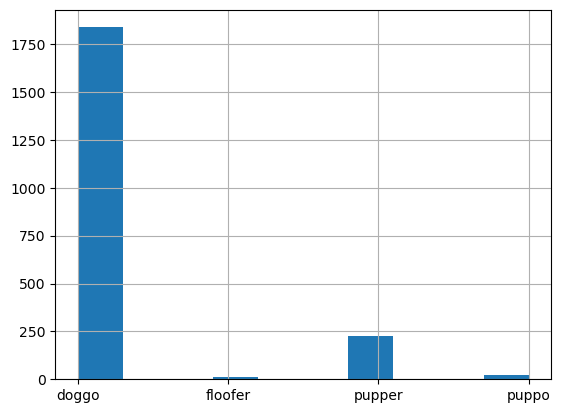

In [493]:
df['age'].hist()

In [ ]:
values = df['age'].value_counts()

age
doggo      1838
pupper      225
puppo        24
floofer      10
Name: count, dtype: int64

In [494]:
freq_age = df['age'].mode()
freq_age

0    doggo
Name: age, dtype: object

> **Conclusion:** The top frequent age is the doggo.

#### **Q2:** What is the top 5 frequent dog breed?

In [497]:
breed_freq = df['breed'].value_counts()
top_5_breed = breed_freq.head(5)
top_5_breed

breed
golden_retriever      196
Labrador_retriever    137
Pembroke              115
Chihuahua             110
pug                    80
Name: count, dtype: int64

<Axes: xlabel='breed'>

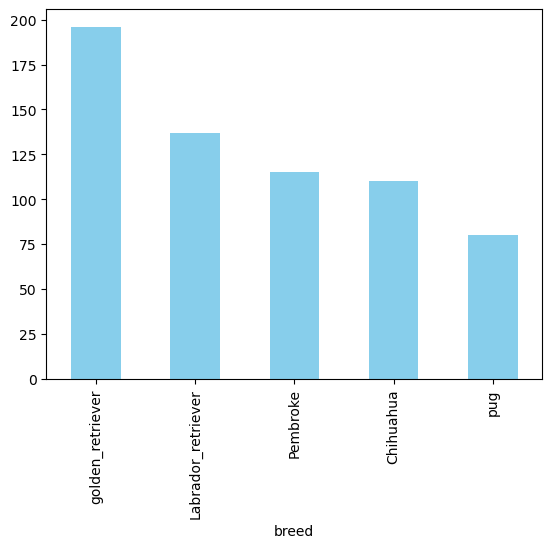

In [501]:
top_5_breed.plot(kind='bar', color='skyblue')

> **Conclusion:** Top 5 frequent breeds are golden_retriever, Labrador_retriever, Pembroke, Chilhuahua, pug.

#### **Q3:** What are the top 5 rated breed?

In [503]:
top_rate_breed = df.groupby('breed')['rating_numerator'].sum().sort_values(ascending=False)
top_rate_breed

breed
golden_retriever        2314
Pekinese                1940
Labrador_retriever      1733
Pembroke                1304
Chihuahua               1116
                        ... 
Bouvier_des_Flandres      13
silky_terrier             12
standard_schnauzer        12
Irish_wolfhound           11
Japanese_spaniel           5
Name: rating_numerator, Length: 113, dtype: int64

In [505]:
top_rated = top_rate_breed.nlargest(5)
top_rated

breed
golden_retriever      2314
Pekinese              1940
Labrador_retriever    1733
Pembroke              1304
Chihuahua             1116
Name: rating_numerator, dtype: int64

<Axes: xlabel='breed'>

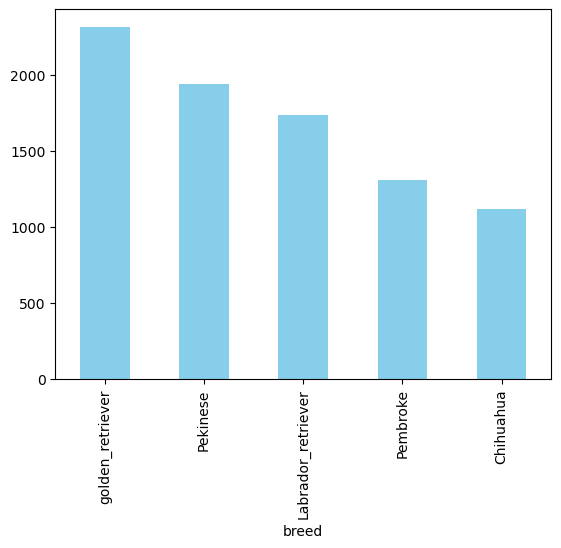

In [512]:
top_rated.plot(kind='bar', color='skyblue')

> **Conclusion:** top rated breeds are:<br>
golden_retriever:      2314<br>
Pekinese:              1940<br>
Labrador_retriever:    1733<br>
Pembroke:              1304<br>
Chihuahua:             1116<br>

#### **Q4:** What is the top favourite age?

In [510]:
top_fav_age = df.groupby('age')['favorite_count'].sum().sort_values(ascending=False)
top_fav_age

age
doggo      16535146
pupper      1635894
puppo        545163
floofer      116749
Name: favorite_count, dtype: int64

<Axes: xlabel='age'>

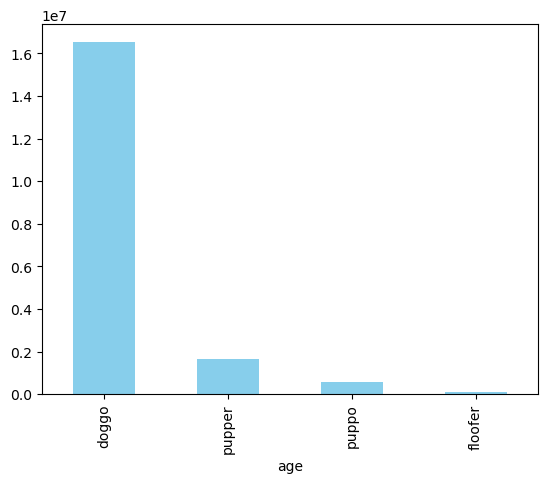

In [511]:
top_fav_age.plot(kind='bar', color='skyblue')

> **Conclusion:** The top favourite age is doggo with total fav_counts = 16535146.